# Recurrent Neural Networks y LSTM

Las **Redes Neuronales Recurrentes** *(RNN)* son modelos diseñados para procesar secuencias de datos donde la información fluye en ciclos, permitiendo mantener una "memoria" de eventos pasados. Sin embargo, sufren del problema de [desvanecimiento de gradiente](https://es.wikipedia.org/wiki/Problema_de_desvanecimiento_de_gradiente), lo que les impide recordar dependencias a largo plazo de forma eficiente.

Las **LSTM** *(Long Short-Term Memory)* son una variante avanzada de las RNN que solucionan esta limitación mediante una estructura de "celda" con compuertas lógicas. Estas puertas controlan qué información se guarda, se olvida o se transmite, permitiendo que la red aprenda y mantenga contextos importantes durante periodos de tiempo mucho más extensos.

<hr>

Para esto se vale de tres tipos de compuertas:

- **Compuerta de olvido (forget gate):** decide que informacion del estado anterior descartar.
- **Compuerta de entrada (input gate):** decide que nueva informacion almacenar en el estado.
- **Compuerta de salida (output gate):** decide que parte del estado se convierte en la salida.

Nos valdremos de su uso para intentar predecir series de tiempo.

## Importo librerias

In [ ]:
!pip install opendatasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
import opendatasets as od

## Importo set de datos

In [ ]:
od.download("https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: martinzwarycz
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data


100%|██████████| 102M/102M [00:01<00:00, 88.7MB/s]


In [ ]:
df = pd.read_csv("bitcoin-historical-data/btcusd_1-min_data.csv")

### Trabajo sobre el set de datos

In [ ]:
print(df.head())

      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


Datos diarios:  5235 dias
Rango temporal: 2012-01-01 00:00:00 -> 2026-05-01 00:00:00


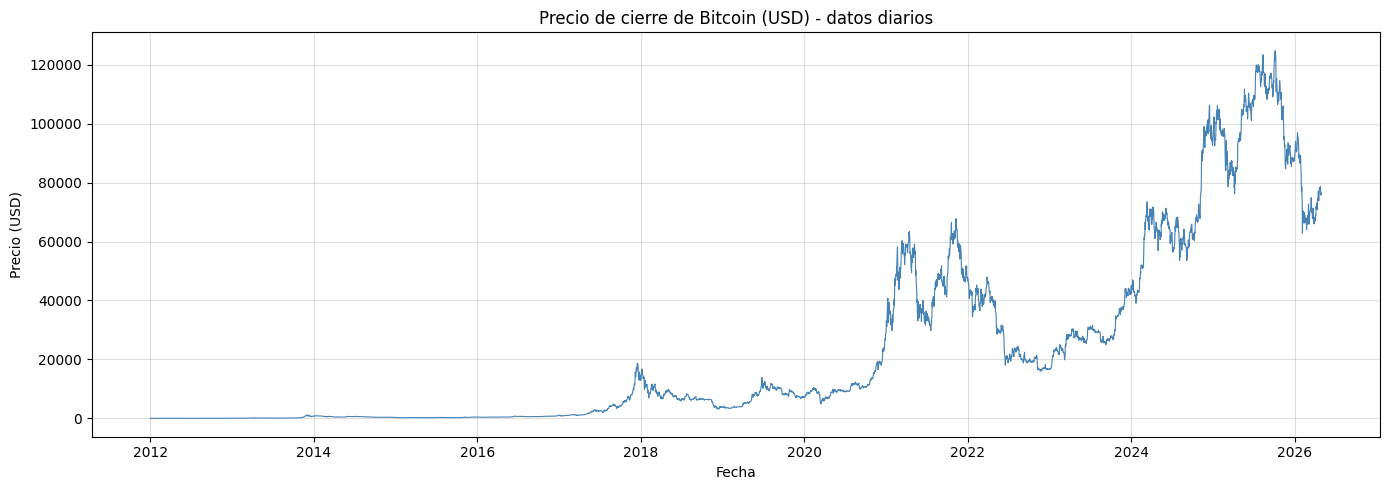

In [ ]:
# El dataset esta en intervalos de 1 minuto; se resamplea a datos diarios para reducir el tamano y facilitar el aprendizaje

df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('Timestamp')

# Resampleo diario tomando el ultimo precio de cierre del dia
df_daily = df['Close'].resample('D').last().dropna()

print("Datos diarios: ", df_daily.shape[0], "dias")
print("Rango temporal:", df_daily.index.min(), "->", df_daily.index.max())

plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily.values, linewidth=0.8, color='steelblue')
plt.title("Precio de cierre de Bitcoin (USD) - datos diarios")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
WINDOW_SIZE = 60  # Usar los ultimos 60 dias para predecir el siguiente

# Normalizacion al rango [0, 1]
scaler = MinMaxScaler()
precios = df_daily.values.reshape(-1, 1)
precios_norm = scaler.fit_transform(precios).flatten()

# Crear secuencias de entrada y etiquetas de salida
def crear_secuencias(serie, window):
    X, y = [], []
    for i in range(len(serie) - window):
        X.append(serie[i:i + window])
        y.append(serie[i + window])
    return np.array(X), np.array(y)

X, y = crear_secuencias(precios_norm, WINDOW_SIZE)
print(f"Forma de X: {X.shape}  (muestras, timesteps)")
print(f"Forma de y: {y.shape}  (muestras,)")

# Division en train (80%) y test (20%) - sin shuffle para respetar el orden temporal
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# La LSTM espera shape (muestras, timesteps, features)
X_train = X_train.reshape(*X_train.shape, 1)
X_test  = X_test.reshape(*X_test.shape, 1)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Forma de X: (5175, 60)  (muestras, timesteps)
Forma de y: (5175,)  (muestras,)
Train: (4140, 60, 1) | Test: (1035, 60, 1)


## Construyo modelo LSTM

In [ ]:
tf.keras.backend.clear_session()

modelo_lstm = tf.keras.Sequential([
    # Primera capa LSTM: procesa la secuencia y devuelve secuencias para la capa siguiente
    layers.LSTM(128, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    layers.Dropout(0.2),

    # Segunda capa LSTM: procesa las secuencias y devuelve solo el ultimo estado oculto
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),

    # Capa densa de transicion
    layers.Dense(32, activation='relu'),

    # Capa de salida: un unico valor (precio del dia siguiente, normalizado)
    layers.Dense(1)
], name="bitcoin_lstm")

modelo_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "bitcoin_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

## Compilo el modelo

In [ ]:
modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

# EarlyStopping para detener el entrenamiento si no hay mejora en validacion
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

historial = modelo_lstm.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - loss: 8.4577e-04 - mae: 0.0152 - val_loss: 1.7837e-04 - val_mae: 0.0091
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 2.6855e-04 - mae: 0.0084 - val_loss: 1.6837e-04 - val_mae: 0.0092
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - loss: 3.0183e-04 - mae: 0.0104 - val_loss: 3.0368e-04 - val_mae: 0.0146
Epoch 4/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - loss: 2.3662e-04 - mae: 0.0090 - val_loss: 1.7804e-04 - val_mae: 0.0102
Epoch 5/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - loss: 2.6113e-04 - mae: 0.0095 - val_loss: 1.2384e-04 - val_mae: 0.0083
Epoch 6/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 1.8219e-04 - mae: 0.0076 - val_loss: 3.0431e-04 - val_mae: 0.0152
Epoch 7/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 2.0871e-04 - mae: 0.0081 - val_loss: 9.4171e-05 - val_mae: 0.0066
Epoch 8/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - loss: 1.8292e-04 - mae: 0.0075 - val_los

## Curva de aprendizaje

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
RMSE en test: $8060.12


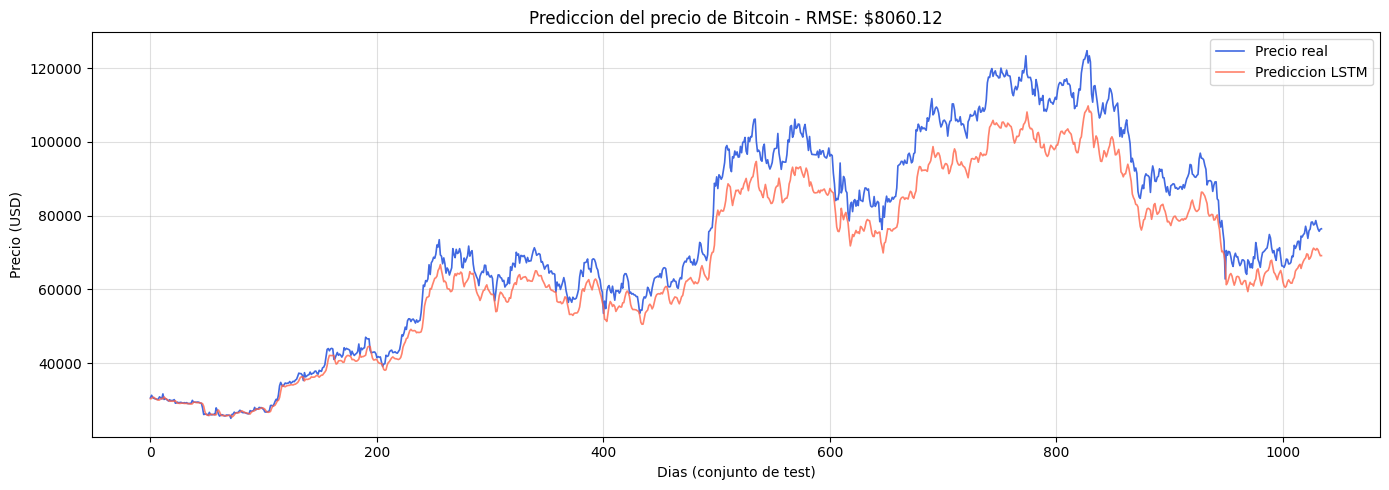

In [ ]:
# Prediccion
y_pred_norm = modelo_lstm.predict(X_test)

# Invertir normalizacion para obtener precios en USD [-1;1] a como estaba previamente
y_pred = scaler.inverse_transform(y_pred_norm)
y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE: https://es.wikipedia.org/wiki/Ra%C3%ADz_del_error_cuadr%C3%A1tico_medio
rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
print(f"RMSE en test: ${rmse:.2f}")

# Grafico de comparacion
plt.figure(figsize=(14, 5))
plt.plot(y_real, label='Precio real', color='royalblue', linewidth=1.2)
plt.plot(y_pred, label='Prediccion LSTM', color='tomato', linewidth=1.2, alpha=0.8)
plt.title(f"Prediccion del precio de Bitcoin - RMSE: ${rmse:.2f}")
plt.xlabel("Dias (conjunto de test)")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()